# Volatility Prediction Model

Predict 5-minute forward volatility for cryptocurrency pairs using LightGBM.

**Why volatility?** Price direction is nearly random, but volatility is persistent and predictable (volatility clustering).

In [23]:
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

np.random.seed(42)

DATA_DIR = Path('../data/historical')
MODEL_DIR = Path('../model')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

## 1. Data Loading

In [6]:
COLUMNS = [
    'timestamp', 'open', 'high', 'low', 'close', 'volume',
    'close_time', 'quote_volume', 'trade_count',
    'taker_buy_base_volume', 'taker_buy_quote_volume', 'ignore'
]

def load_data(data_dir):
    dfs = []
    for f in sorted(data_dir.glob('*.csv')):
        df = pd.read_csv(f, names=COLUMNS, header=None)
        df['symbol'] = f.stem.split('-')[0].upper()
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='us')
        dfs.append(df.drop(columns=['close_time', 'ignore']))
    # Sort by symbol first for feature engineering (groupby), will re-sort by timestamp later
    return pd.concat(dfs, ignore_index=True).sort_values(['symbol', 'timestamp']).reset_index(drop=True)

df = load_data(DATA_DIR)
print(f'Loaded {len(df):,} rows | {df["symbol"].nunique()} symbols')
print(f'Date range: {df["timestamp"].min()} -> {df["timestamp"].max()}')

Loaded 1,728,000 rows | 40 symbols
Date range: 2025-11-01 00:00:00 -> 2025-11-30 23:59:00


## 2. Feature Engineering

In [7]:
def add_features(df):
    df = df.copy()
    g = df.groupby('symbol')
    
    df['return_1m'] = g['close'].pct_change() * 100
    df['return_5m'] = g['close'].pct_change(5) * 100
    df['return_15m'] = g['close'].pct_change(15) * 100
    
    for w in [5, 15, 30, 60]:
        df[f'volatility_{w}m'] = g['return_1m'].transform(lambda x: x.rolling(w, min_periods=1).std())
    
    df['volatility_ratio'] = df['volatility_5m'] / (df['volatility_30m'] + 1e-8)
    df['price_range_pct'] = (df['high'] - df['low']) / (df['close'] + 1e-8) * 100
    df['price_body_pct'] = abs(df['close'] - df['open']) / (df['close'] + 1e-8) * 100
    
    for w in [15, 60]:
        ma = g['volume'].transform(lambda x: x.rolling(w, min_periods=1).mean())
        df[f'volume_ratio_{w}m'] = df['volume'] / (ma + 1e-8)
    
    df['buy_ratio'] = df['taker_buy_base_volume'] / (df['volume'] + 1e-8)
    df['buy_sell_imbalance'] = (2 * df['taker_buy_base_volume'] - df['volume']) / (df['volume'] + 1e-8)
    
    trade_ma = g['trade_count'].transform(lambda x: x.rolling(15, min_periods=1).mean())
    df['trade_intensity'] = df['trade_count'] / (trade_ma + 1e-8)
    
    for w in [15, 60]:
        price_ma = g['close'].transform(lambda x: x.rolling(w, min_periods=1).mean())
        df[f'price_vs_ma_{w}m'] = (df['close'] - price_ma) / (price_ma + 1e-8) * 100
    
    df['hour'] = df['timestamp'].dt.hour
    df['volatility_next_5m'] = g['volatility_5m'].shift(-5)
    return df

df = add_features(df)
print(f'Features: {df.shape[1]} columns')

Features: 30 columns


In [8]:
FEATURE_COLS = [
    'return_1m', 'return_5m', 'return_15m',
    'volatility_5m', 'volatility_15m', 'volatility_30m', 'volatility_60m', 'volatility_ratio',
    'price_range_pct', 'price_body_pct',
    'volume_ratio_15m', 'volume_ratio_60m',
    'buy_ratio', 'buy_sell_imbalance',
    'trade_intensity',
    'price_vs_ma_15m', 'price_vs_ma_60m',
    'hour',
]

df_clean = df.dropna(subset=['volatility_next_5m'] + FEATURE_COLS).copy()
# IMPORTANT: Sort by timestamp for proper TimeSeriesSplit (all symbols at each time slice)
df_clean = df_clean.sort_values('timestamp').reset_index(drop=True)
print(f'Clean data: {len(df_clean):,} rows ({len(df_clean)/len(df)*100:.1f}%)')
print(f'Sorted by timestamp for TimeSeriesSplit')

Clean data: 1,727,200 rows (100.0%)
Sorted by timestamp for TimeSeriesSplit


## 3. EDA

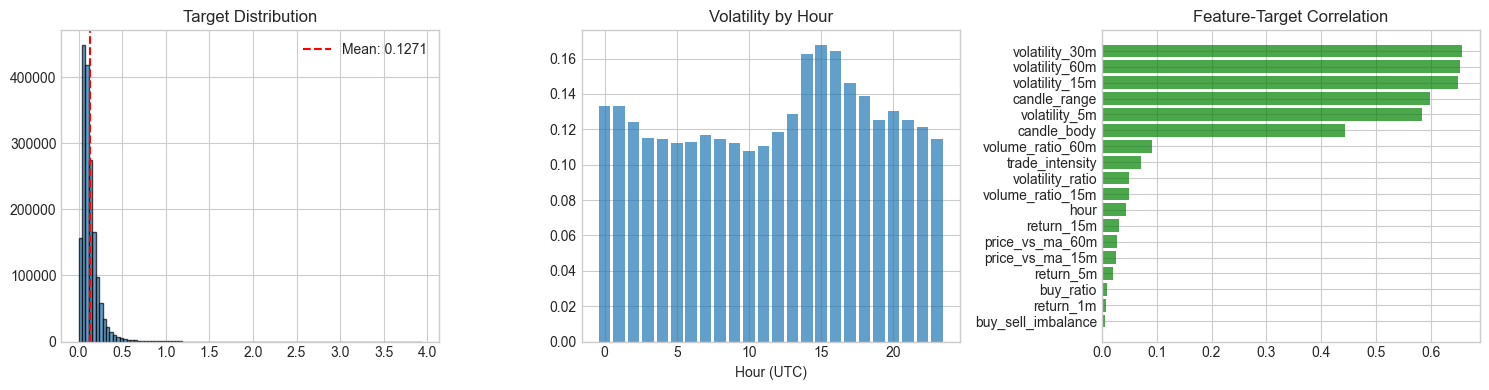

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_clean['volatility_next_5m'], bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(df_clean['volatility_next_5m'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["volatility_next_5m"].mean():.4f}')
axes[0].set_title('Target Distribution')
axes[0].legend()

hourly = df_clean.groupby('hour')['volatility_next_5m'].mean()
axes[1].bar(hourly.index, hourly.values, alpha=0.7)
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_title('Volatility by Hour')

target_corr = df_clean[FEATURE_COLS + ['volatility_next_5m']].corr()['volatility_next_5m'].drop('volatility_next_5m').sort_values(key=abs, ascending=True)
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
axes[2].barh(target_corr.index, target_corr.values, color=colors, alpha=0.7)
axes[2].set_title('Feature-Target Correlation')

plt.tight_layout()
plt.show()

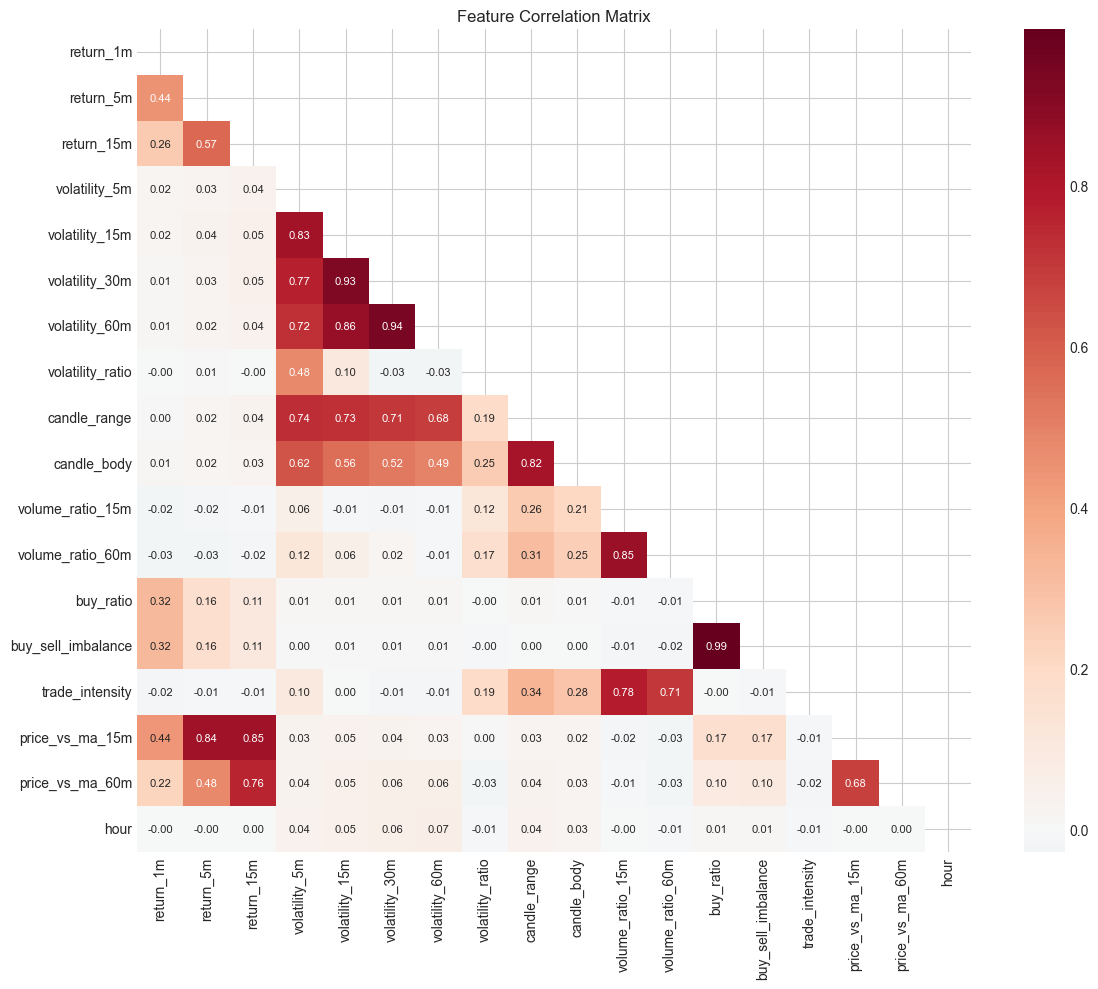

In [10]:
corr_matrix = df_clean[FEATURE_COLS].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. Feature Selection

In [11]:
le = LabelEncoder()
df_clean['symbol_encoded'] = le.fit_transform(df_clean['symbol'])
all_features = FEATURE_COLS + ['symbol_encoded']

# Prepare data for feature selection (use first 60% train, next 20% val)
X_all = df_clean[all_features].values.astype(np.float32)
y_all = df_clean['volatility_next_5m'].values.astype(np.float32)
X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)

n = len(X_all)
train_end = int(n * 0.6)
X_train_sel, y_train_sel = X_all[:train_end], y_all[:train_end]
X_val_sel, y_val_sel = X_all[train_end:int(n*0.8)], y_all[train_end:int(n*0.8)]

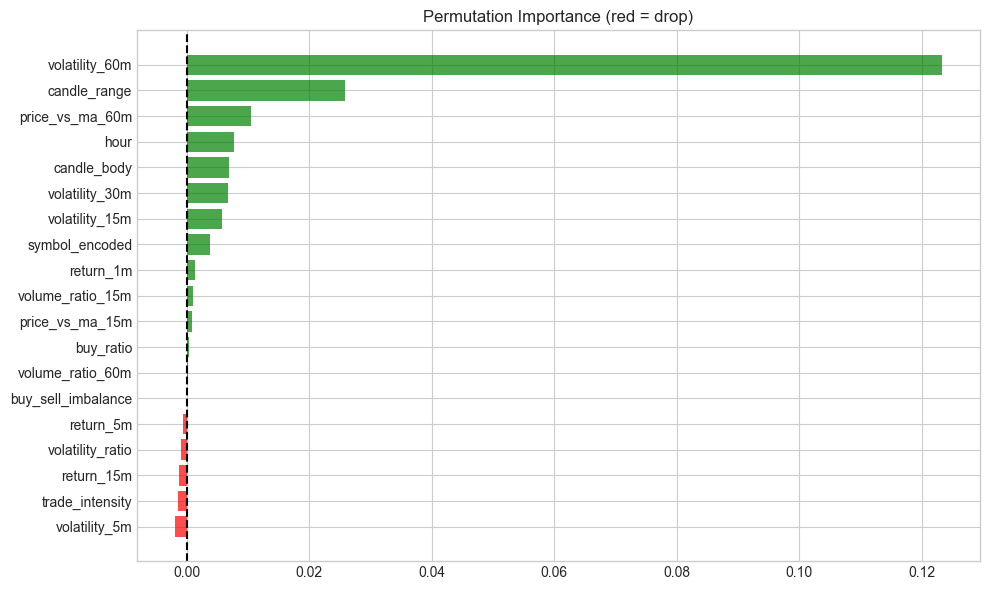


Selected 14/19 features
['return_1m', 'volatility_15m', 'volatility_30m', 'volatility_60m', 'price_range_pct', 'price_body_pct', 'volume_ratio_15m', 'volume_ratio_60m', 'buy_ratio', 'buy_sell_imbalance', 'price_vs_ma_15m', 'price_vs_ma_60m', 'hour', 'symbol_encoded']


In [12]:
# Train baseline model
baseline = lgb.LGBMRegressor(n_estimators=100, verbosity=-1, random_state=42)
baseline.fit(X_train_sel, y_train_sel)

# Permutation importance
perm = permutation_importance(baseline, X_val_sel, y_val_sel, n_repeats=10, random_state=42, n_jobs=-1)

# Visualize
imp_df = pd.DataFrame({'feature': all_features, 'importance': perm.importances_mean}).sort_values('importance')
plt.figure(figsize=(10, 6))
colors = ['red' if x <= 0 else 'green' for x in imp_df['importance']]
plt.barh(imp_df['feature'], imp_df['importance'], color=colors, alpha=0.7)
plt.axvline(0, color='black', linestyle='--')
plt.title('Permutation Importance (red = drop)')
plt.tight_layout()
plt.show()

# Select features with positive importance
selected_features = [f for f, imp in zip(all_features, perm.importances_mean) if imp > 0]
print(f'\nSelected {len(selected_features)}/{len(all_features)} features')
print(selected_features)

## 5. Data Preparation (TimeSeriesSplit)

In [13]:
# Prepare arrays with selected features
X = df_clean[selected_features].values.astype(np.float32)
y = df_clean['volatility_next_5m'].values.astype(np.float32)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
feature_names = selected_features

# Hold out final 20% for test (never touched during CV)
test_size = int(len(X) * 0.2)
X_trainval, X_test = X[:-test_size], X[-test_size:]
y_trainval, y_test = y[:-test_size], y[-test_size:]

print(f'Train+Val: {len(X_trainval):,} | Test (holdout): {len(X_test):,}')

Train+Val: 1,381,760 | Test (holdout): 345,440


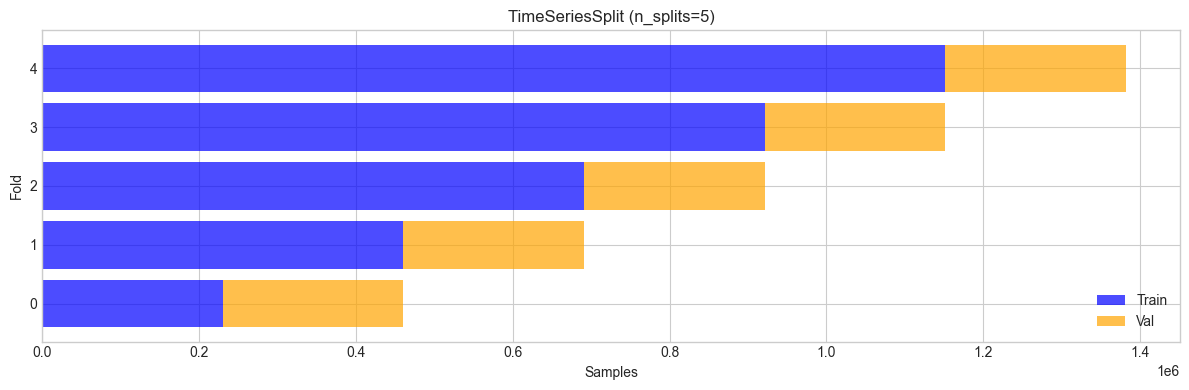

Fold 1: Train=230,295 | Val=230,293
Fold 2: Train=460,588 | Val=230,293
Fold 3: Train=690,881 | Val=230,293
Fold 4: Train=921,174 | Val=230,293
Fold 5: Train=1,151,467 | Val=230,293


In [14]:
# TimeSeriesSplit visualization
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

fig, ax = plt.subplots(figsize=(12, 4))
for i, (train_idx, val_idx) in enumerate(tscv.split(X_trainval)):
    ax.barh(i, len(train_idx), left=0, color='blue', alpha=0.7, label='Train' if i == 0 else '')
    ax.barh(i, len(val_idx), left=len(train_idx), color='orange', alpha=0.7, label='Val' if i == 0 else '')
ax.set_xlabel('Samples')
ax.set_ylabel('Fold')
ax.set_title(f'TimeSeriesSplit (n_splits={N_SPLITS})')
ax.legend()
plt.tight_layout()
plt.show()

# Print fold sizes
for i, (train_idx, val_idx) in enumerate(tscv.split(X_trainval)):
    print(f'Fold {i+1}: Train={len(train_idx):,} | Val={len(val_idx):,}')

## 6. Hyperparameter Tuning (Optuna + TimeSeriesSplit CV)

In [15]:
def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'feature_pre_filter': False,
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    
    # Cross-validate with TimeSeriesSplit
    scores = []
    for train_idx, val_idx in tscv.split(X_trainval):
        train_data = lgb.Dataset(X_trainval[train_idx], label=y_trainval[train_idx], feature_name=feature_names)
        val_data = lgb.Dataset(X_trainval[val_idx], label=y_trainval[val_idx], reference=train_data)
        
        model = lgb.train(
            params, train_data,
            num_boost_round=500,
            valid_sets=[val_data],
            callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)],
        )
        pred = model.predict(X_trainval[val_idx])
        scores.append(np.sqrt(mean_squared_error(y_trainval[val_idx], pred)))
    
    return np.mean(scores)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest CV RMSE: {study.best_value:.5f}')
print(f'Best params: {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[31]	valid_0's rmse: 0.0936271
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[16]	valid_0's rmse: 0.0793116
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[35]	valid_0's rmse: 0.0711647
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[60]	valid_0's rmse: 0.0705901
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[49]	valid_0's rmse: 0.0773389
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[60]	valid_0's rmse: 0.0941123
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[42]	valid_0's rmse: 0.0795143
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[41]	valid_0's 

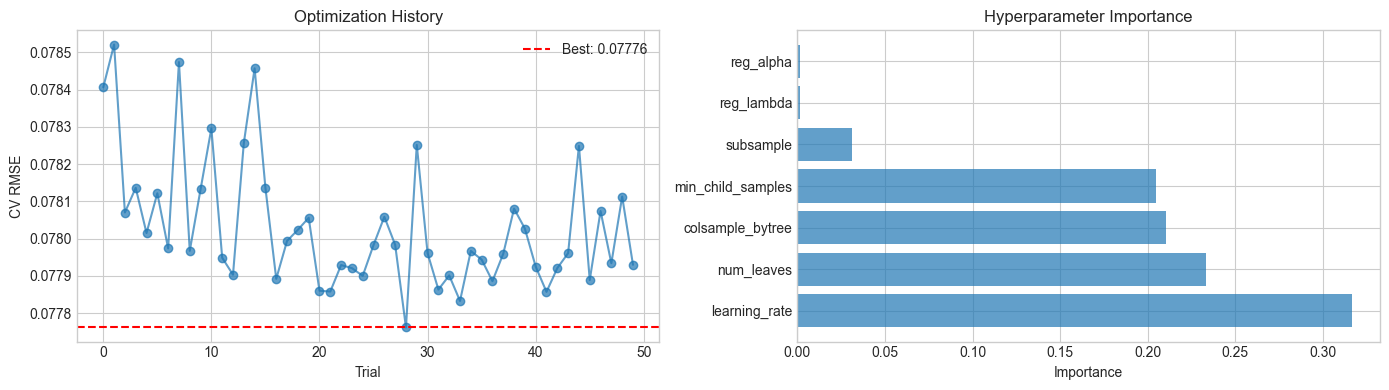

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], 'o-', alpha=0.7)
axes[0].axhline(study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:.5f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CV RMSE')
axes[0].set_title('Optimization History')
axes[0].legend()

importance = optuna.importance.get_param_importances(study)
axes[1].barh(list(importance.keys()), list(importance.values()), alpha=0.7)
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importance')

plt.tight_layout()
plt.show()

## 7. Cross-Validation Results (with best params)

In [17]:
# Evaluate stability across folds with best params
best_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'feature_pre_filter': False,
    **study.best_params,
}

scores = []
for train_idx, val_idx in tscv.split(X_trainval):
    train_data = lgb.Dataset(X_trainval[train_idx], label=y_trainval[train_idx], feature_name=feature_names)
    val_data = lgb.Dataset(X_trainval[val_idx], label=y_trainval[val_idx], reference=train_data)
    
    model = lgb.train(
        best_params, train_data,
        num_boost_round=500,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
    )
    
    pred = model.predict(X_trainval[val_idx])
    y_val = y_trainval[val_idx]
    scores.append((np.sqrt(mean_squared_error(y_val, pred)), mean_absolute_error(y_val, pred), r2_score(y_val, pred)))

scores = np.array(scores)
print('Cross-Validation Results:')
for i, (rmse, mae, r2) in enumerate(scores, 1):
    print(f'Fold {i}: RMSE={rmse:.5f} | MAE={mae:.5f} | R2={r2:.4f}')
print(f'\nMean: RMSE={scores[:, 0].mean():.5f} | MAE={scores[:, 1].mean():.5f} | R2={scores[:, 2].mean():.4f}')
print(f'Std:  RMSE={scores[:, 0].std():.5f} | MAE={scores[:, 1].std():.5f} | R2={scores[:, 2].std():.4f}')

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[171]	valid_0's rmse: 0.092003
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[78]	valid_0's rmse: 0.078641
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[80]	valid_0's rmse: 0.070864
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[498]	valid_0's rmse: 0.0702857
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[494]	valid_0's rmse: 0.0769767
Cross-Validation Results:
Fold 1: RMSE=0.09200 | MAE=0.05345 | R2=0.5811
Fold 2: RMSE=0.07864 | MAE=0.04802 | R2=0.5052
Fold 3: RMSE=0.07086 | MAE=0.04845 | R2=0.4124
Fold 4: RMSE=0.07029 | MAE=0.04718 | R2=0.4248
Fold 5: RMSE=0.07698 | MAE=0.04755 | R2=0.3507

Mean: RMSE=0.07775 | MAE=0.04893 | R2=0.4549
Std:  RMSE=0.00784 | MAE=0.00230

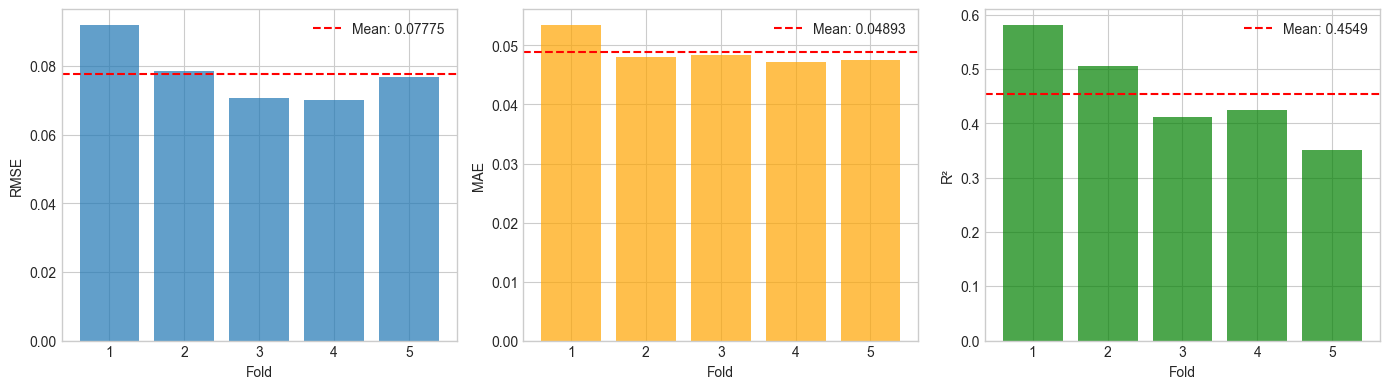

In [18]:
# Visualize CV results
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
folds = range(1, len(scores) + 1)

axes[0].bar(folds, scores[:, 0], alpha=0.7)
axes[0].axhline(scores[:, 0].mean(), color='red', linestyle='--', label=f'Mean: {scores[:, 0].mean():.5f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('RMSE')
axes[0].legend()

axes[1].bar(folds, scores[:, 1], alpha=0.7, color='orange')
axes[1].axhline(scores[:, 1].mean(), color='red', linestyle='--', label=f'Mean: {scores[:, 1].mean():.5f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('MAE')
axes[1].legend()

axes[2].bar(folds, scores[:, 2], alpha=0.7, color='green')
axes[2].axhline(scores[:, 2].mean(), color='red', linestyle='--', label=f'Mean: {scores[:, 2].mean():.4f}')
axes[2].set_xlabel('Fold')
axes[2].set_ylabel('R²')
axes[2].legend()

plt.tight_layout()
plt.show()

## 8. Final Training (on all train+val data)

In [19]:
# Split validation from trainval for early stopping (avoid test leakage)
val_size = int(len(X_trainval) * 0.15)
X_train_final, y_train_final = X_trainval[:-val_size], y_trainval[:-val_size]
X_val_final, y_val_final = X_trainval[-val_size:], y_trainval[-val_size:]

train_data = lgb.Dataset(X_train_final, label=y_train_final, feature_name=feature_names)
val_data = lgb.Dataset(X_val_final, label=y_val_final, reference=train_data)

evals_result = {}
model = lgb.train(
    best_params, train_data,
    num_boost_round=500,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50), lgb.record_evaluation(evals_result)],
)

print(f'Best iteration: {model.best_iteration}')

Training until validation scores don't improve for 50 rounds
[50]	train's rmse: 0.0827909	val's rmse: 0.0661032
[100]	train's rmse: 0.0802564	val's rmse: 0.0657063
[150]	train's rmse: 0.0794711	val's rmse: 0.0655706
[200]	train's rmse: 0.0790468	val's rmse: 0.0655029
[250]	train's rmse: 0.0786727	val's rmse: 0.065459
[300]	train's rmse: 0.0783607	val's rmse: 0.0654273
[350]	train's rmse: 0.0780292	val's rmse: 0.0654168
[400]	train's rmse: 0.0777572	val's rmse: 0.0654208
Early stopping, best iteration is:
[366]	train's rmse: 0.0779379	val's rmse: 0.0654141
Best iteration: 366


## 9. Final Evaluation (Holdout Test Set)

In [20]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Holdout Test Results:')
print(f'RMSE={rmse:.5f} | MAE={mae:.5f} | R2={r2:.4f}')
print(f'\nCV Mean: RMSE={scores[:, 0].mean():.5f} | R2={scores[:, 2].mean():.4f}')
print(f'Gap (Test - CV): RMSE={rmse - scores[:, 0].mean():+.5f} | R2={r2 - scores[:, 2].mean():+.4f}')

Holdout Test Results:
RMSE=0.04851 | MAE=0.03296 | R2=0.3609

CV Mean: RMSE=0.07775 | R2=0.4549
Gap (Test - CV): RMSE=-0.02924 | R2=-0.0940


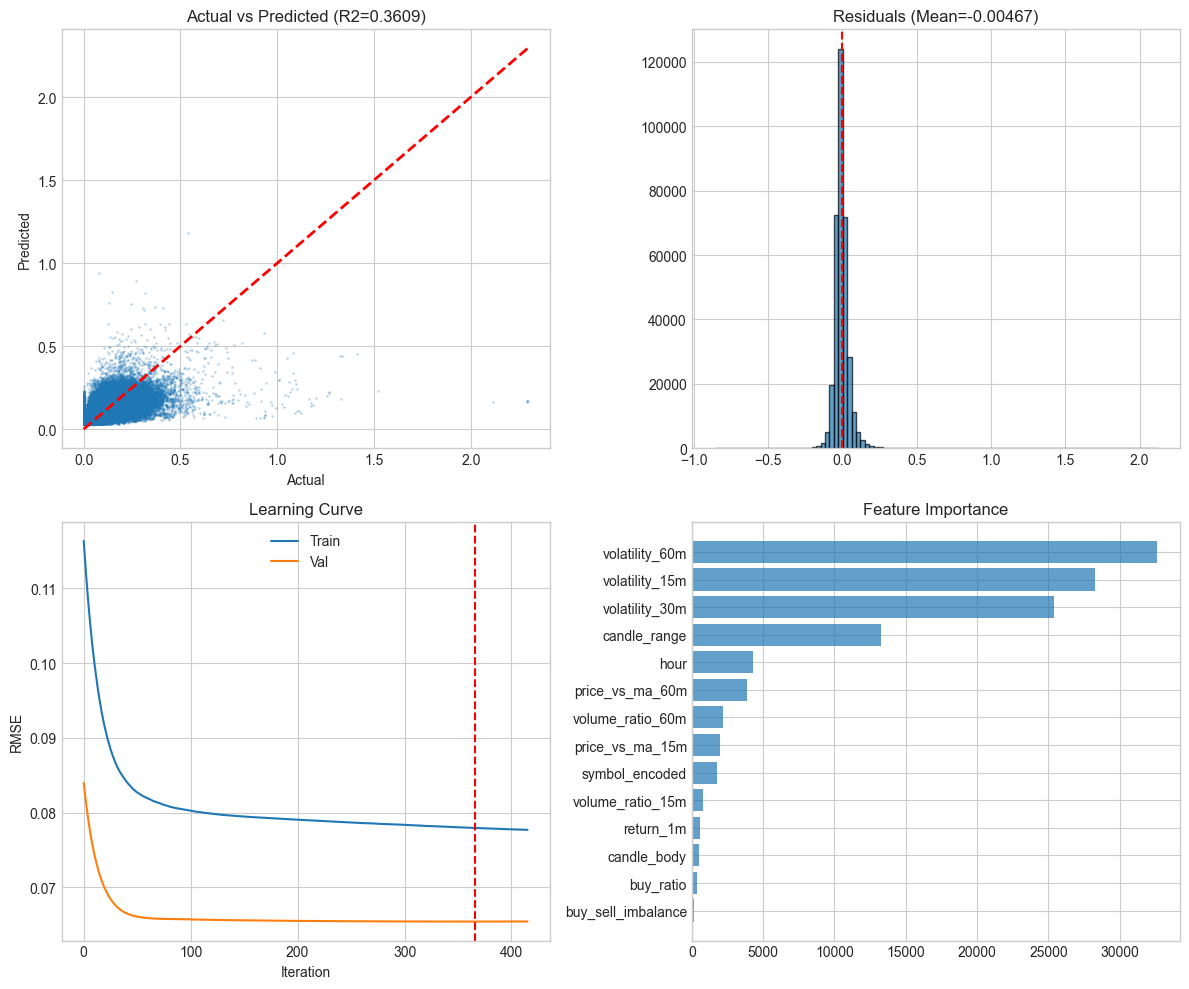

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(y_test, y_pred, alpha=0.2, s=1)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')
axes[0, 0].set_title(f'Actual vs Predicted (R2={r2:.4f})')

residuals = y_test - y_pred
axes[0, 1].hist(residuals, bins=100, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--')
axes[0, 1].set_title(f'Residuals (Mean={residuals.mean():.5f})')

axes[1, 0].plot(evals_result['train']['rmse'], label='Train')
axes[1, 0].plot(evals_result['val']['rmse'], label='Val')
axes[1, 0].axvline(model.best_iteration, color='red', linestyle='--')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].set_title('Learning Curve')
axes[1, 0].legend()

importance = model.feature_importance(importance_type='gain')
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importance}).sort_values('importance')
axes[1, 1].barh(imp_df['feature'], imp_df['importance'], alpha=0.7)
axes[1, 1].set_title('Feature Importance')

plt.tight_layout()
plt.show()

## 10. Save Model

In [24]:
model.save_model(str(MODEL_DIR / 'volatility_predictor.json'))
print(f'Model saved: {MODEL_DIR / "volatility_predictor.json"}')

Model saved: ../model/volatility_predictor.json
